# Parallel LangGraph Workflow for Cricket Stats

In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [8]:
class CricketState(TypedDict):
    player_name: str
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    balls_per_boundary: float
    boundary_runs_percentage: float
    summary: str

def calculate_strike_rate(state: CricketState):
    runs = state.get("runs", 0)
    balls = state.get("balls", 0)
    sr = round((runs / balls) * 100, 2) if balls > 0 else 0.0
    return {"strike_rate": sr}

def calculate_balls_per_boundary(state: CricketState):
    balls = state.get("balls", 0)
    fours = state.get("fours", 0)
    sixes = state.get("sixes", 0)
    total_boundaries = fours + sixes
    bpb = round(balls / total_boundaries, 2) if total_boundaries > 0 else float('inf')
    return {"balls_per_boundary": bpb}

def calculate_boundary_percentage(state: CricketState):
    runs = state.get("runs", 0)
    fours = state.get("fours", 0)
    sixes = state.get("sixes", 0)
    boundary_runs = (fours * 4) + (sixes * 6)
    br_pct = round((boundary_runs / runs) * 100, 2) if runs > 0 else 0.0
    return {"boundary_runs_percentage": br_pct}

def generate_summary(state: CricketState):
    player = state.get("player_name", "Player")
    sr = state.get("strike_rate", 0.0)
    bpb = state.get("balls_per_boundary", 0.0)
    br_pct = state.get("boundary_runs_percentage", 0.0)
    
    bpb_str = str(bpb) if bpb != float('inf') else "N/A"
    
    summary_str = (
        f"Player: {player} | "
        f"Strike Rate: {sr} | "
        f"Balls per Boundary: {bpb_str} | "
        f"Boundary Runs %: {br_pct}%"
    )
    return {"summary": summary_str}

In [9]:
workflow = StateGraph(CricketState)

# Add nodes
workflow.add_node("calc_strike_rate", calculate_strike_rate)
workflow.add_node("calc_balls_per_boundary", calculate_balls_per_boundary)
workflow.add_node("calc_boundary_percentage", calculate_boundary_percentage)
workflow.add_node("generate_summary", generate_summary)

# Parallel execution from START
workflow.add_edge(START, "calc_strike_rate")
workflow.add_edge(START, "calc_balls_per_boundary")
workflow.add_edge(START, "calc_boundary_percentage")

# Join parallel steps to generate_summary
workflow.add_edge("calc_strike_rate", "generate_summary")
workflow.add_edge("calc_balls_per_boundary", "generate_summary")
workflow.add_edge("calc_boundary_percentage", "generate_summary")

workflow.add_edge("generate_summary", END)

app = workflow.compile()

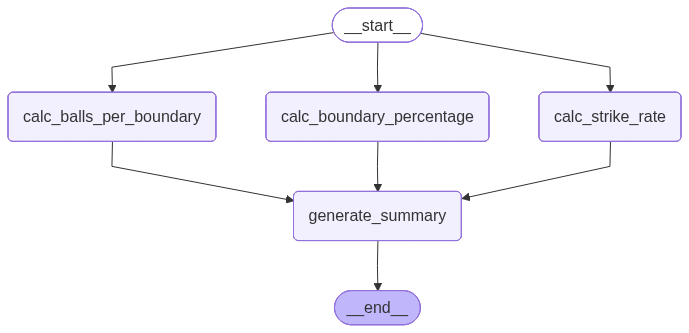

In [10]:
from IPython.display import Image, display
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

In [ ]:
input_data = {
    "player_name": "MS Dhoni",
    "runs": 28,
    "balls": 15, 
    "fours": 2,
    "sixes": 2
}

output = app.invoke(input_data)
print(output["summary"])

Player: MS Dhoni | Strike Rate: 186.67 | Balls per Boundary: 3.75 | Boundary Runs %: 71.43%
